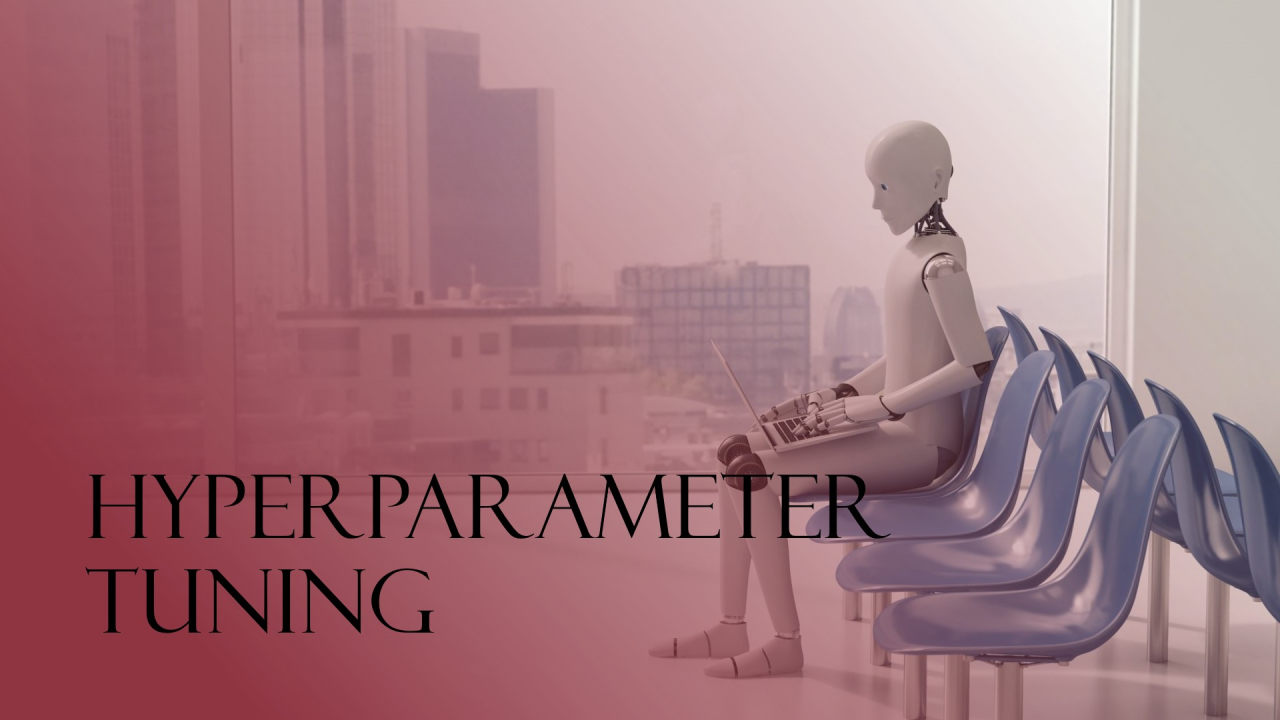

# **HYPERPARAMETER TUNING AND MODEL SELECTION**

## **Objectives**

- To perform hyperparameter tuning using GridSearchCV and RandomizedSearchCV.
- To optimize KNN and Random Forest models.
- To create and tune machine learning pipelines.
- To implement nested cross-validation.
- To compare Grid Search and Random Search performance.
- To work with suitable built-in datasets from `sklearn.datasets`.

In [1]:
# Common libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

## **1. Tune KNN using GridSearchCV**

### **Objective**

To tune the hyperparameters of a K-Nearest Neighbors (KNN) classifier using GridSearchCV and identify the best parameter combination for the Iris dataset.

In [2]:
# Import the dataset
from sklearn.datasets import load_iris

In [3]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Create pipeline
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [5]:
# Perform GridSearchCV
grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [6]:
print("Best Parameters:", grid_knn.best_params_)
print(f"Best CV Accuracy: {grid_knn.best_score_:.4f}")

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.9667


## **2. Tune Random Forest using RandomizedSearchCV**

### **Objective**

To optimize a Random Forest classifier using RandomizedSearchCV and identify a high-performing combination of hyperparameters for the Wine dataset.

In [7]:
# Import the dataset
from sklearn.datasets import load_wine

In [8]:
# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Select the Random Forest Model and parameters
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

In [10]:
# Perform RandomizedSearchCV
random_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb3be17f4d0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb3be17ca50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb3be4cbcb0>},
                   random_state=42, scoring='accuracy')

In [11]:
print("Best Parameters:", random_rf.best_params_)
print(f"Best CV Accuracy: {random_rf.best_score_:.4f}")


Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 314}
Best CV Accuracy: 0.9862


In [12]:
# Evaluate best Random Forest model
rf_pred = random_rf.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Test Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## **3. Create a pipeline and tune parameters**

### **Objective**

To create a machine learning pipeline that combines feature scaling and Support Vector Machine classification, and tune its parameters using GridSearchCV on the Digits dataset.

In [13]:
# Import the dataset
from sklearn.datasets import load_digits

In [14]:
# Load Digits dataset
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Create pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

In [16]:
# Perform GridSearchCV
grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 'auto'],
                         'svm__kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [17]:
print("Best Parameters:", grid_svm.best_params_)
print(f"Best CV Accuracy: {grid_svm.best_score_:.4f}")

Best Parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Accuracy: 0.9833


In [18]:
# Evaluate tuned pipeline
svm_pred = grid_svm.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

Test Accuracy: 0.9750

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



## **4. Implement nested cross-validation**

### **Objective**

To implement nested cross-validation for hyperparameter tuning and obtain an unbiased estimate of model performance using the Breast Cancer dataset.

In [19]:
# Import the dataset
from sklearn.datasets import load_breast_cancer

In [20]:
# Load Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [21]:
# Define pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

param_grid_lr = {
    "logistic__C": [0.01, 0.1, 1, 10, 100],
    "logistic__solver": ["liblinear", "lbfgs"]
}

In [22]:
# Perform Stratified K-Fold
inner_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

outer_cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

In [23]:
# Perform GridSearchCV as nested model
nested_model = GridSearchCV(
    logistic_pipeline,
    param_grid_lr,
    cv=inner_cv,
    scoring="accuracy",
    n_jobs=-1
)

nested_scores = cross_val_score(
    nested_model,
    X,
    y,
    cv=outer_cv,
    scoring="accuracy",
    n_jobs=-1
)

In [24]:
print("Nested CV Scores:", np.round(nested_scores, 4))
print(f"Mean Nested CV Accuracy: {nested_scores.mean():.4f}")
print(f"Standard Deviation: {nested_scores.std():.4f}")

Nested CV Scores: [0.9825 0.9561 0.9649 0.9912 0.9912]
Mean Nested CV Accuracy: 0.9772
Standard Deviation: 0.0142


## **5. Compare Grid Search and Random Search results**

### **Objective**

To compare GridSearchCV and RandomizedSearchCV using the same model and dataset, and determine which hyperparameter search strategy provides better performance.

In [25]:
# Import the dataset
from sklearn.datasets import load_diabetes

In [26]:
# Load Diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = (diabetes.target > np.median(diabetes.target)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
# Perform Random Forest
rf = RandomForestClassifier(random_state=42)

In [28]:
# Grid Search parameters
grid_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf,
    grid_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [29]:
print("Grid Search Best Parameters:")
print(grid_search.best_params_)
print(f"Grid Search Best CV Accuracy: {grid_search.best_score_:.4f}")

Grid Search Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Grid Search Best CV Accuracy: 0.7394


In [30]:
# Random Search parameters
random_params = {
    "n_estimators": randint(100, 500),
    "max_depth": [5, 10, 15, None],
    "min_samples_split": randint(2, 10),
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf,
    random_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb3be0f6fd0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb3be0f7490>},
                   random_state=42, scoring='accuracy')

In [31]:
print("Random Search Best Parameters:")
print(random_search.best_params_)
print(f"Random Search Best CV Accuracy: {random_search.best_score_:.4f}")

Random Search Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 120}
Random Search Best CV Accuracy: 0.7281


In [32]:
# Compare test performance
grid_pred = grid_search.predict(X_test)
random_pred = random_search.predict(X_test)

grid_test_acc = accuracy_score(y_test, grid_pred)
random_test_acc = accuracy_score(y_test, random_pred)

comparison = pd.DataFrame({
    "Method": ["Grid Search", "Random Search"],
    "Best CV Accuracy": [
        grid_search.best_score_,
        random_search.best_score_
    ],
    "Test Accuracy": [
        grid_test_acc,
        random_test_acc
    ]
})

comparison = comparison.round(4)
comparison

,Method,Best CV Accuracy,Test Accuracy
0,Grid Search,0.7394,0.7303
1,Random Search,0.7281,0.7528


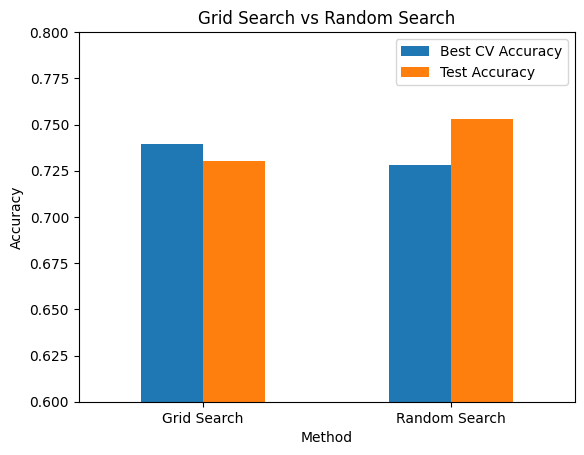

In [33]:
# Plot comparison
comparison.plot(
    x="Method",
    y=["Best CV Accuracy", "Test Accuracy"],
    kind="bar"
)

plt.ylabel("Accuracy")
plt.title("Grid Search vs Random Search")
plt.ylim(0.6, 0.8)
plt.xticks(rotation=0)
plt.show()

## **Conclusion**

- **KNN with GridSearchCV:** Identified the best KNN hyperparameters through an exhaustive grid search.
- **Random Forest with RandomizedSearchCV:** Efficiently searched the parameter space to obtain an optimized Random Forest model.
- **Pipeline and Tuning:** Combined preprocessing and model training in a pipeline and tuned its parameters.
- **Nested Cross-Validation:** Provided a reliable estimate of model performance while reducing evaluation bias.
- **Grid Search vs Random Search:** Compared both tuning methods based on their cross-validation and test performance.

Overall, Hyperparameter tuning and proper cross-validation help improve model selection and provide more reliable machine learning results.

---
### **Completed By:** *Monish D.Y. - 230701195*